# Visualization of Time Series

In [2]:
from statsmodels.tsa.stattools import acf
import pandas as pd


df = pd.read_csv("https://www.alphavantage.co/query?function=TIME_SERIES_DAILY&symbol=IBM&apikey=demo&datatype=csv", parse_dates=['timestamp'], index_col = 'timestamp')

df.head()

,open,high,low,close,volume
timestamp,,,,,
2024-01-19,170.59,171.5791,169.180,171.48,6929079
2024-01-18,166.49,166.9900,165.040,166.84,3776990
2024-01-17,166.79,167.8200,165.495,166.08,4288604
2024-01-16,165.80,167.2500,165.340,166.96,4869635
2024-01-12,162.97,165.9800,162.355,165.80,4958261


## Line plots

<AxesSubplot:xlabel='timestamp'>

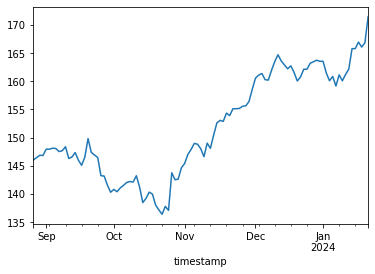

In [4]:
df = df.asfreq('B')

df['close'] = df['close'].fillna(method='ffill')

df['close'].plot()



## Seasonal decomposition plots

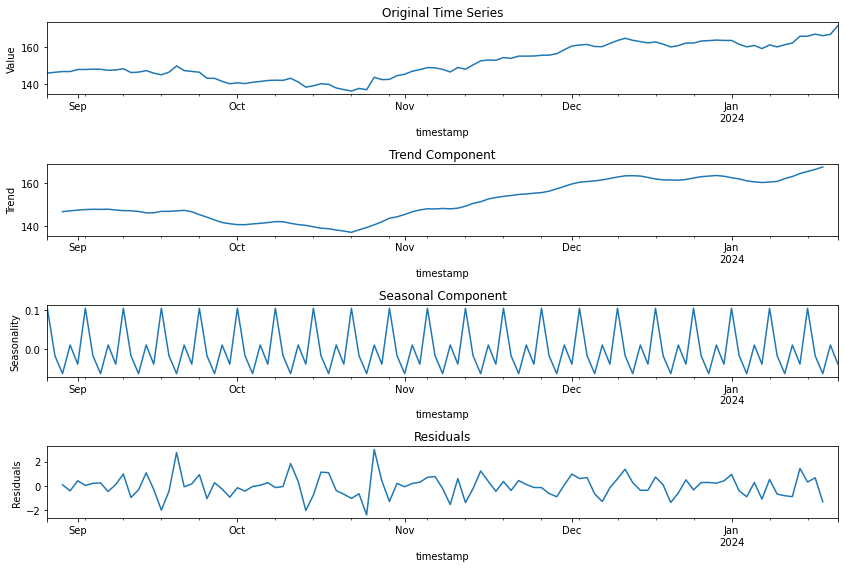

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Decompose the time series
decomposition = seasonal_decompose(df['close'], model='additive')

# Plot the decomposition
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(12, 8))
df['close'].plot(ax=ax1, title='Original Time Series')
ax1.set_ylabel('Value')
decomposition.trend.plot(ax=ax2, title='Trend Component')
ax2.set_ylabel('Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonal Component')
ax3.set_ylabel('Seasonality')
decomposition.resid.plot(ax=ax4, title='Residuals')
ax4.set_ylabel('Residuals')

plt.tight_layout()
plt.show()

## Autocorrelation and partial autocorrelation plots

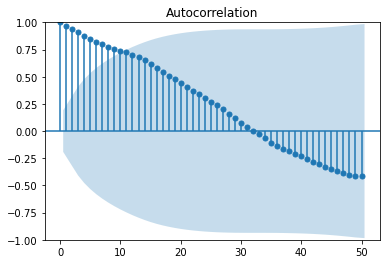

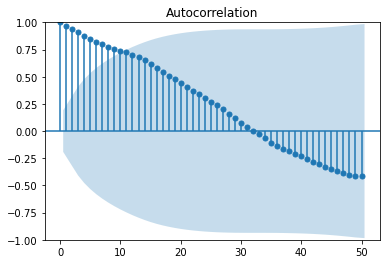

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm


sm.graphics.tsa.plot_acf(df.close.dropna().squeeze(), lags=50)